# Workflows and Agents with LangGraph


This notebook is a hands-on companion to the LangGraph "Workflows and Agents" guide. It walks through every pattern in the guide, in order, with runnable code cells.

> **Workflows** have predetermined code paths and are designed to operate in a certain order.
>
> **Agents** are dynamic and define their own processes and tool usage.

![Agent vs Workflow](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/agent_workflow.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=c217c9ef517ee556cae3fc928a21dc55)

LangGraph offers several benefits when building agents and workflows, including **persistence**, **streaming**, and support for **debugging** and **deployment**.

## Table of Contents

1. [Setup](#1.-Setup)
2. [LLMs and Augmentations](#2.-LLMs-and-Augmentations)
3. [Prompt Chaining](#3.-Prompt-Chaining)
4. [Parallelization](#4.-Parallelization)
5. [Routing](#5.-Routing)
6. [Orchestrator-Worker](#6.-Orchestrator-Worker)
7. [Evaluator-Optimizer](#7.-Evaluator-Optimizer)
8. [Agents](#8.-Agents)
9. [ToolNode](#9.-ToolNode)

Each pattern (where the source provides it) is shown two ways:
- **Graph API** — build an explicit `StateGraph` of nodes and edges.
- **Functional API** — write plain Python functions decorated with `@task` / `@entrypoint`.

Both compile down to the same underlying LangGraph runtime — pick whichever style fits your codebase.

## 1. Setup

To build a workflow or agent, you can use any chat model that supports structured outputs and tool calling. This notebook uses **OpenAI's GPT models** as the example model.

### Install dependencies

In [1]:
%pip install -q langchain_core langchain-openai langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Initialize the LLM

In [2]:
import os
import getpass

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# Load environment variables (e.g. OPENAI_API_KEY) from the .env file
load_dotenv(r"E:\ACADEMY CLASS NOTEBOOKS\.env")


def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-5-nano")

## 2. LLMs and Augmentations

Workflows and agentic systems are based on LLMs and the various augmentations you add to them. **Tool calling**, **structured outputs**, and **short-term memory** are a few options for tailoring LLMs to your needs.

![LLM augmentations](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/augmented_llm.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=7ea9656f46649b3ebac19e8309ae9006)

In [ ]:
# Schema for structured output
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str | None = Field(
        default=None, description="Query that is optimized web search."
    )
    justification: str | None = Field(
        default=None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")
print(output)  # The model returns an instance of SearchQuery.

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")
print(msg.tool_calls)  # The model returns a request to call the tool.

search_query='How coronary artery calcium score relates to high cholesterol' justification='The user is asking about the connection between CAC score from a calcium CT and high cholesterol, likely for risk assessment and management of cholesterol-lowering therapy.'


[]


## 3. Prompt Chaining

Prompt chaining is when each LLM call processes the output of the previous call. It's often used for well-defined tasks that can be broken down into smaller, verifiable steps. Examples include:

- Translating documents into different languages
- Verifying generated content for consistency

![Prompt chaining](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/prompt_chain.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=762dec147c31b8dc6ebb0857e236fc1f)

### 3.1 Graph API

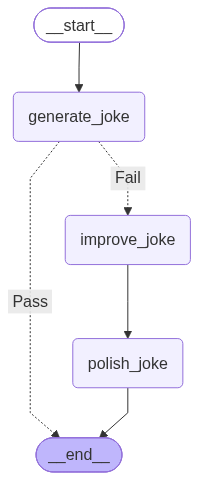

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [5]:
# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
Why did the cat sit on the computer? It wanted to keep an eye on the mouse.

--- --- ---

Final joke:
Why did the cat sit on the computer? It wanted to keep an eye on the mouse.


## 4. Parallelization

With parallelization, LLMs work simultaneously on a task. This is either done by running multiple independent subtasks at the same time, or running the same task multiple times to check for different outputs. Parallelization is commonly used to:

- Split up subtasks and run them in parallel, which increases speed
- Run tasks multiple times to check for different outputs, which increases confidence

Examples include:
- Running one subtask that processes a document for keywords, and a second subtask to check for formatting errors
- Running a task multiple times that scores a document for accuracy based on different criteria (citations, sources used, source quality)

![Parallelization](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/parallelization.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=8afe3c427d8cede6fed1e4b2a5107b71)

### 4.1 Graph API

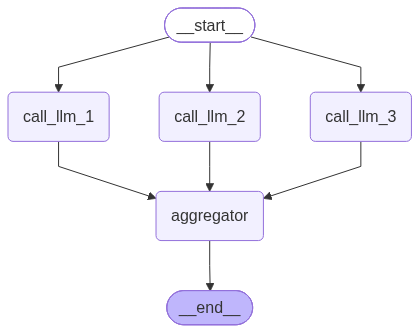

In [7]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [8]:
# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
In Maplebay, where the wind tastes like salt and the roofs whispered with the soft patter of rain, three cats kept watch over the harbor after dark. They were known to the fishmongers and the fishermen, though not by name to every soul: a sleepy gray cat named Clover, a jittery orange tabby called Pippin, and a black cat with a gleam in his eyes who answered to Ember. They called themselves the Night Watch, not because danger always lurked, but because there was beauty in the hour when the town slid from day into night and every creak in the docks became a melody.

Maplebay’s lighthouse stood at the end of a jet of rock, a great stone sentinel that pressed against the sea with a patient, stubborn hope. They say the light was more a memory than a flame nowadays, that the keeper’s lamp needed more than oil to burn correctly—it needed the town’s courage, too, and a bit of luck. On many nights, Clover would nap in the lee of a crate and li

## 5. Routing

Routing workflows process inputs and then direct them to context-specific tasks. This allows you to define specialized flows for complex tasks. For example, a workflow built to answer product-related questions might process the type of question first, and then route the request to specific processes for pricing, refunds, returns, etc.

![Routing](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/routing.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=272e0e9b681b89cd7d35d5c812c50ee6)

### 5.1 Graph API

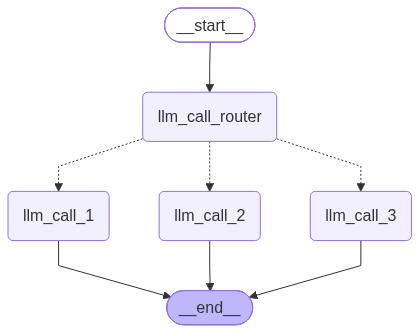

In [10]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [11]:
# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

Why don't cats play poker in the jungle? Too many cheetahs.


## 6. Orchestrator-Worker

In an orchestrator-worker configuration, the orchestrator:

- Breaks down tasks into subtasks
- Delegates subtasks to workers
- Synthesizes worker outputs into a final result

![Orchestrator-worker](https://mintcdn.com/langchain-5e9cc07a/ybiAaBfoBvFquMDz/oss/images/worker.png?fit=max&auto=format&n=ybiAaBfoBvFquMDz&q=85&s=2e423c67cd4f12e049cea9c169ff0676)

Orchestrator-worker workflows provide more flexibility and are often used when subtasks **cannot** be predefined the way they can with [parallelization](#4.-Parallelization). This is common with workflows that write code or need to update content across multiple files — e.g. updating installation instructions for multiple Python libraries across an unknown number of documents.

### 6.1 Defining the planning schema (shared by both APIs)

In [13]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

### 6.3 Creating workers in LangGraph (Graph API + `Send`)

Orchestrator-worker workflows are common and LangGraph has built-in support for them. The `Send` API lets you dynamically create worker nodes and send them specific inputs. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and lets it synthesize them into a final output.

The example below iterates over a list of sections and uses the `Send` API to send a section to each worker.

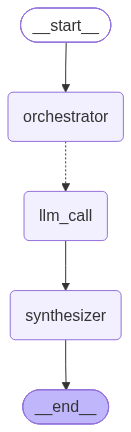

In [15]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [16]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

## Executive Summary

Large Language Model (LLM) scaling laws describe predictable, empirical relationships between model size (parameters), data (tokens), compute, and resulting performance. These laws provide a roadmap for designing models, budgeting resources, and planning development timelines. In short, bigger models trained on more data with sufficient compute tend to perform better, but with diminishing returns that vary by context. Balancing resources across model size, data volume, and compute is essential to achieving the best possible performance within a fixed budget.

Key takeaways for design and planning

- Model size matters, but returns diminish. Increasing parameters yields substantial gains early on, but each incremental growth provides smaller improvements as models get larger. Beyond a point, gains may be outweighed by the cost and the risk of overfitting or inefficiencies if data and compute are not scaled accordingly.

- Data is a central driver of performance. More and higher-quality data generally yields stronger gains than equivalent increases in model size at later stages. Data quality, diversity, and deduplication significantly affect learning efficiency and generalization.

- Compute budget shapes feasible configurations. Given a fixed compute budget, there is a practical balance between N (model size) and D (data tokens) that maximizes performance. Empirically, balanced allocations tend to outperform extreme emphasis on one dimension.

- A widely cited balance rule of thumb (from recent scaling research) suggests aligning data and parameters to a roughly fixed data-per-parameter ratio. For autoregressive LLMs, this has been described as approximately 20 tokens of data per model parameter (D ≈ 20 × N) to optimize the use of compute. Under a compute budget C, this implies N ∝ sqrt(C/20) and D ∝ sqrt(20C). These relationships are approximate and depend on architecture, data, and training setup, but they provide a practical planning heuristic.

- Emergent capabilities scale with size. As models reach larger scales, certain capabilities (e.g., complex reasoning, multi-step planning) can appear or improve more rapidly. This highlights the importance of scale when aiming for advanced behaviors, while also underscoring the need for careful evaluation and safety considerations as models grow.

- Practical implications for resource planning:
  - Set performance targets and translate them into a budget: determine an overall compute ceiling, then allocate N and D to approach the target within that budget.
  - Prioritize data strategy alongside model architecture: investments in data collection, cleaning, and curation often yield high returns.
  - Plan for iteration: use scaling experiments to validate the applicability of scaling laws to your specific task, data, and hardware.

What this means for your development workflow

- For new model development, start with a balanced scaling plan rather than “always bigger models.” Estimate the compute budget, apply the D ≈ 20N heuristic as a starting point, and adjust based on validation performance and practical constraints (latency, memory, data availability).

- Invest early in data infrastructure. High-quality, diverse data improves sample efficiency and can unlock gains without proportionally increasing model size.

- Monitor diminishing returns. Track how performance scales with each additional batch of data or increase in parameters, and reallocate resources if marginal gains drop below a threshold.

- Factoring in deployment realities. Larger models demand more inference compute and memory. Align scaling choices with deployment constraints (latency targets, cost per token, and hardware availability) to ensure the model remains usable in production.

- Use scaling laws as a planning tool, not a prophecy. They provide direction for resource allocation and feasibility assessment, but actual gains depend on dataset distribution, training regime, regularization, optimization stability, and safety requirements.

Limitations and caveats

- Scaling laws are empirical and context-dependent. They describe broad trends and may not precisely predict performance for every architecture, dataset, or task distribution.

- Extrapolations beyond the observed ranges (e.g., drastically larger models or radically different data mixes) carry risk. Validate with controlled experiments and monitoring.

- Safety, alignment, and reliability considerations do not scale exactly in the same way as raw performance metrics. As you scale, ensure governance, evaluation, and risk mitigation keep pace with capability gains.

- Data concerns matter as much as technical scaling. Data curation, representativeness, privacy, and copyright considerations can constrain how aggressively you can scale data.

In summary, LLM scaling laws provide a practical framework for resource planning and model design: scale model size and data thoughtfully, balance compute across both dimensions, and account for diminishing returns while preparing for emergent capabilities and deployment realities. This balanced, evidence-backed approach supports cost-effective progress toward higher-performance language models.

---

## Background and Key Concepts

Scaling laws describe how model performance improves as we allocate more resources to training large language models (LLMs). In this context, three primary resources are considered: model size, data, and compute. Empirically, these resources interact to produce approximate power-law relationships between resource level and performance, which can be visualized as straight lines on log-log plots. Understanding these relationships helps researchers and practitioners forecast gains from scaling and allocate resources efficiently.

### Key variables

- N: Number of model parameters (model size). Increasing N generally improves the model’s capacity to learn and represent complex patterns.
- D: Dataset size (often measured in tokens or examples). More data provides more diverse signals for training, which can improve generalization.
- C: Compute budget. The total amount of compute used to train the model, typically measured in FLOPs (floating-point operations) or an equivalent measure of training effort. For a fixed training setup, C increases with longer training, larger models, or larger datasets.

### Power-law behavior and log-log relationships

- Power-law scaling: In many regimes, performance metrics (for example, validation loss or perplexity) exhibit a power-law relationship with each resource, such as L ∝ N^(-α), L ∝ D^(-β), and L ∝ C^(-γ), where α, β, γ > 0 are exponents that quantify the sensitivity of performance to each resource.
- Log-log interpretation: When you plot log(performance) against log(N), log(D), or log(C), you often observe approximately straight-line relationships. The slopes of these lines correspond to the negative exponents (−α, −β, −γ), providing a compact summary of how strongly each resource influences performance.
- Combined scaling forms: In practice, performance depends on all three resources. A commonly used phenomenological form is L(N, D, C) ≈ L∞ + a N^(-α) + b D^(-β) + c C^(-γ), where L∞ represents an irreducible error floor due to data noise or model misalignment, and a, b, c are constants. More sophisticated forms include interaction terms, but the additive approximation captures the essence of the scaling behavior in many settings.

### Diminishing returns

- Diminishing returns: The exponents are typically less than one, meaning that each successive increase in N, D, or C yields smaller incremental improvements in performance. This is the hallmark of a power-law regime: doubling a resource does not double the gain and the benefit per unit resource decreases as you scale up.
- Practical implication: There exists an optimal allocation of resources given constraints. Beyond a certain point, investing more in one resource yields diminishing marginal gains unless other resources are scaled in tandem.

### Common terminology

- Scaling laws: Empirical or theoretical descriptions of how performance scales with N, D, and C.
- Power-law: A functional form of the type X ∝ Y^p, where p is the scaling exponent.
- Log-log relationship: A plot of log(X) versus log(Y) that yields a straight line in the scaling regime.
- Exponent (α, β, γ): The slopes (in log-log space) that quantify how sensitively performance responds to changes in N, D, and C, respectively.
- Irreducible loss (L∞): The horizon performance cannot be exceeded by scaling resources alone, due to noise, task limit, or architectural factors.
- Datasets and tokens: The data units used for training; datasets are often described by the number of tokens they contain.
- Compute budget: The total computational effort expended during training, typically expressed in FLOPs.
- Regime vs. regime boundaries: The scaling laws are most accurate in certain regions (e.g., very large N or D); departures can occur outside those regimes.

This background establishes the language and expected behavior used to reason about scaling in LLMs and to interpret empirical scaling studies.

---

## The Scaling Law Framework

Scaling laws describe how a quantity of interest Y changes as a function of one or more controlling variables (e.g., data, model size, compute, or architectural choices). They are often captured by power-law forms, with possible cross-over between regimes and saturation as resources become limiting. The following forms and their interpretations provide a practical toolkit for describing, visualizing, and testing scaling in machine learning and related systems.

### Mathematical forms

- Single-variable power law
  - Y = A X^α
  - Log form: log Y = log A + α log X
  - Interpretation: Y grows as a fixed power of X with exponent α.

- Multivariable power law
  - Y = A X^α Z^β
  - Log form: log Y = log A + α log X + β log Z
  - Interpretation: Y scales jointly with X and Z; exponents α and β quantify each variable’s contribution.

- Cross-over regimes (piecewise and smooth)
  - Piecewise (two regimes with a knee Xc):
    - Y = { A1 X^α1, for X ≤ Xc
           A2 X^α2, for X > Xc }
  - Smooth cross-over (continuous transition):
    - Y = A X^α1 [1 + (X/Xc)^{Δ}]^{-(α1−α2)/Δ}
  - Interpretation: Different scaling laws apply in different regimes; Xc marks a transition point.

- Saturation effects
  - Exponential saturation:
    - Y = Ymax (1 − e^(−k X))
  - Hill-type (sigmoidal) saturation:
    - Y = Ymax X^n / (K^n + X^n)
  - Multi-variable saturation (one can generalize to multiple regulators):
    - Y ≈ Ymax ∏i [X_i^{α_i} / (K_i^{α_i} + X_i^{α_i})]
  - Interpretation: Y grows with X but approaches a finite ceiling as resources saturate or competition for capacity increases.

### Visualization and interpretation

- Single-variable power laws
  - Use a log-log plot: plot log Y vs log X. A straight line indicates a power law, with slope equal to α.
  - Residuals on the log-log axis reveal deviations from a pure power law and potential cross-overs or saturation.

- Multivariable scaling
  - Fix one variable and examine log Y vs log of the other variable(s).
  - Contour or heat maps of log Y in the (log X, log Z) plane visualize how Y scales jointly; multiple slices or 3D plots can reveal interactions.
  - Alternatively, fit a linear model in log space: log Y = log A + α log X + β log Z, and inspect residuals.

- Cross-over regimes
  - Look for changes in slope (the local exponent) across regimes in log-log plots.
  - Piecewise regression or segmented regression can quantify breakpoints Xc and exponents α1, α2.
  - Data collapse around a knee can indicate a universal transition mechanism.

- Saturation
  - In log-log coordinates, saturation shows as an initial linear increase followed by a plateau or slower growth.
  - Fit saturating models (Hill or exponential) and compare to a pure power law using information criteria (AIC/BIC) or cross-validation.
  - Plot derivatives dY/dX to visualize diminishing returns as X grows.

### Factors that can affect the scaling laws

- Architecture
  - Model family (e.g., transformers, CNNs, MLPs) and architectural details (depth, width, attention heads) can shift exponents and knee locations.
  - Larger or more capable architectures may push regimes further before cross-overs occur or saturations set in.

- Data quality and quantity
  - Data volume, diversity, and annotation noise influence the effective information content.
  - Noisier or less representative data often reduces the usable range for a clean power-law region and can lower observed exponents or induce early saturation.
  - Distribution shift or dataset heterogeneity can create apparent cross-overs or regime-specific exponents.

- Training duration and compute
  - The amount of training (steps, compute budget) determines whether a system is in the asymptotic scaling regime or still in transient growth.
  - Early training can exhibit steeper or different scaling than mature training; diminishing returns may appear sooner with limited compute.

- Hyperparameters and optimization dynamics
  - Learning rate schedules, regularization, and optimization tricks can alter the effective scaling by changing sample efficiency and convergence speed.
  - These factors can modify both the apparent exponents and the location of cross-overs or saturations.

- Task and metric choice
  - Different objectives (e.g., error rate, cross-entropy loss, perplexity, accuracy) exhibit different scaling behavior.
  - Metrics that saturate by design (e.g., accuracy approaching 1) will show saturation effects clearly.

### Practical guidance for applying the framework

- Start simple
  - Begin with a single-variable power-law fit to establish a baseline exponent.
- Test for additional structure
  - If residuals show systematic patterns, introduce a second variable and test a multivariable power law.
  - Look for knee regions suggesting cross-overs; consider segmented regression or a smooth cross-over model.
  - Check for saturation in regimes where increasing X yields diminishing gains; fit saturating forms if appropriate.
- Use proper fitting and validation
  - Fit in log space for power laws; use nonlinear least squares or Bayesian methods for saturating or cross-over forms.
  - Validate models with held-out data or cross-validation; compare alternatives with AIC/BIC or predictive accuracy.
- Diagnose with visualization
  - Employ log-log plots, residuals, and contour plots to diagnose regime structure.
  - Use data-collapse techniques, if applicable, to test universality across settings (e.g., different architectures or datasets).
- Communicate regime structure clearly
  - Report estimated exponents, knee locations (Xc), saturation parameters (Ymax, K), and confidence intervals.
  - Describe domain-specific implications: what the exponents imply about efficiency, capacity, or data utilization; what cross-overs and saturations mean for scaling budgets.

---

## Empirical Core Scaling Laws and Evidence

Empirical scaling laws describe how model performance (often measured by loss) improves as we increase model size, data, or compute. Landmark studies show that, in many regimes, these improvements follow (approximately) power-law relationships with diminishing returns. The results are remarkably consistent across domains (language, vision, multimodal) and architectures, though the exact exponents vary by task, data distribution, and training setup.

- Core idea and general form
  - Loss L tends to follow a power-law decay as we scale individual resources, often captured in a three-way relationship among model size (N), data (D), and compute (C). In practical terms, increasing any one resource while holding the others fixed yields predictable reductions in cross-entropy or task loss, with improvements that diminish as the resource grows.
  - A common summarized form used in the foundational work is that loss can be approximated by a baseline plus power-law terms in each resource:
    - L(N, D, C) ≈ L∞ + a_N · N^(-α) + a_D · D^(-β) + a_C · C^(-γ)
    - Here α, β, γ are positive exponents (typical of order less than 1) that quantify how quickly loss improves with each resource.

- Landmark empirical findings
  - Kaplan et al. (2020) demonstrated robust power-law scaling for neural language models across large ranges of model sizes and data, showing that test loss decreases as a power of model size and data under fixed compute, with consistent diminishing returns as one resource grows. Their framework also highlighted near-universal trends: if you scale one resource without corresponding adjustments in others, you observe predictable, quasi-linear behavior in log-log plots of loss vs resource.
  - Datasets, architectures, and regimes matter: the exact exponents are not universal constants. They depend on the domain (language vs vision vs multimodal), the data distribution, model family, and whether you are in the underfit, fit, or overfit regime. Across tasks, however, the exponents tend to be small positive numbers, indicating diminishing returns but ongoing gains with scale.
  - Chinchilla (Hoffmann et al., 2022) refined the practical implications: for a fixed compute budget, it is often more data-efficient to train a smaller model with more data rather than a larger model with the same compute. They articulated a compute-optimal regime where the data-to-parameter ratio is driven by the budget and architectural choices, with the takeaway that data scaling and parameter scaling must be balanced to maximize performance per compute.
  - Vision and multimodal scaling laws extend the language-model findings: similar power-law behavior with respect to model size and data has been observed in vision transformers and multimodal models, reinforcing the view that scale laws are a broad phenomenon rather than a language-specific artifact.

- Typical ranges for scaling exponents (domains)
  - General observation: exponents α (model size), β (data), and γ (compute) are positive but O(0.1–0.3) in many mid-to-large regimes. Exact values vary by task and regime.
  - Language modeling (as a reference domain for foundational scaling laws):
    - α (loss vs model size) often reported in the mid-range of ~0.1–0.3.
    - β (loss vs data) typically smaller but still positive, often ~0.05–0.2.
    - γ (loss vs compute) similar order of magnitude, reflecting that compute scaling yields meaningful gains but with diminishing returns.
  - Vision (scaling laws for vision transformers and similar architectures):
    - α and β generally in the same broad ranges as language tasks, though sometimes with somewhat lower β (data scaling) sensitivity in tightly curated vision datasets.
    - Compute scaling (γ) remains impactful, with diminishing returns as models and data grow beyond practical budgets.
  - Multimodal and cross-domain work:
    - Exponents tend to align with the same qualitative picture: positive, small <1 exponents with pronounced diminishing returns, and domain-specific adjustments depending on data diversity, alignment requirements, and architectural choices.

- Practical implications and caveats
  - Scaling laws are most reliable in the mid-to-large regime with plenty of data and compute; they can under- or over-predict gains in very small models or extremely limited data regimes.
  - The exponents are not universal constants; practitioners should treat them as guiding trends rather than precise levers. They provide a basis for forecasting, budgeting, and trade-offs between model size and data collection efforts.
  - The optimal allocation of resources often follows the compute-optimal insights (e.g., Chinchilla-style recommendations): beyond a point, spending compute to grow a model yields smaller gains than using that compute to train with more data on a smaller model, all else equal.

- Takeaways for forecasting and planning
  - Expect loss to decline as a power-law with increases in N, D, and C, with diminishing returns as you scale.
  - For a given compute budget, a data-heavy, smaller-model approach can outperform larger models trained with the same compute.
  - Use the scaling-law intuition to budget experiments: forecasts of performance gains should consider not just increasing one resource, but the joint, balanced scaling of model size and data, guided by domain-specific exponents and practical constraints.

Overall, empirical core scaling laws provide a cohesive, quantitative lens for understanding how performance scales with resources across domains, while allowing for domain-specific calibration of the scaling exponents and the practical trade-offs between data, compute, and model size.

---

## Compute-Optimal Scaling and Data-Compute Trade-offs

Compute-optimal scaling asks: given a fixed compute budget, how should one balance model size (parameters) and data (tokens) to maximize performance? The core insight from the Chinchilla work is that, at fixed compute, performance improves more by increasing data (tokens) than by enlarging the model beyond a modest size. In practical terms, there exists a favorable data-to-parameter ratio that yields higher returns than simply scaling up parameters alone.

Key insights from the Chinchilla work (Hoffmann et al., 2022):
- Data-first scaling under compute constraints: For a given compute budget, training with more data and a smaller-to-moderate model can outperform training a much larger model on less data.
- A practical rule-of-thumb: roughly 20 tokens per model parameter (D ≈ 20N) tended to appear in their compute-optimal regime. This ratio implies that to reach compute-optimal performance, you should proportionally emphasize data more than you would if you were aiming to maximize model size.
- Predictable trade-off: If you increase model size, you should increase data roughly in step to maintain the same ratio; otherwise, returns plateau or diminish.
- Data quality matters: Beyond sheer quantity, dataset quality, deduplication, alignment, and domain coverage are critical to realizing the gains predicted by scaling laws.
- Robust across regimes: While the exact numbers depend on architecture and training setup, the qualitative message—data scaling is a primary driver of compute-efficient gains—held consistently across studied settings.

Practical implications for budgeting and planning:
- Start with a data-to-parameter ratio baseline: use D ≈ 20N as a guiding target when planning new models or budgets.
- Budget planning steps:
  - Step 1: Fix your total compute budget (C), in practical terms, the time, hardware, and energy you’re willing to allocate to training.
  - Step 2: Choose a baseline model size N that fits your use case and hardware constraints.
  - Step 3: Set D ≈ 20N and assess whether the resulting compute cost C’ ≈ k × N × D (where k captures architecture- and training-constant factors) aligns with your budget. If not, adjust N downward (and thus D) or revise the training plan (e.g., fewer epochs, different optimization settings).
  - Step 4: Develop a data acquisition and engineering plan to reliably reach the target D, prioritizing data quality, deduplication, and diversity.
  - Step 5: Iterate with small-scale experiments to calibrate the data-to-parameter balance for your exact setup before committing to full-scale training.
- Data-centric investment: Prioritize data collection, cleaning, and curation as a core part of the budget, since gains from scaling data can exceed gains from scaling parameters at a fixed compute budget.
- Phased scaling plan:
  - Phase 1: Validate with a smaller N and D that approximate the 20:1 ratio to establish a baseline.
  - Phase 2: Incrementally scale N and D together to maintain the ratio, monitoring performance gains and compute usage.
  - Phase 3: Once the ratio proves effective, push toward the compute budget ceiling with careful monitoring and safety checks.
- Practical caveats:
  - The 20:1 ratio is a useful guideline but not a universal law; real-world results depend on data quality, tokenization, domain alignment, and model architecture.
  - Accessibility and data licensing can constrain the feasible amount of data you can collect for training.
  - Consider safety, alignment, and regulatory requirements as you scale data, not just model size.
- Quick takeaway: For compute-efficient LLM scaling, aim to train smaller-to-moderate models on much larger, higher-quality datasets, guided by the D ≈ 20N heuristic, and treat data engineering as a central component of the budgeting process.

---

## Practical Guidance for Scaling LLMs

Translate scaling laws into actionable guidance for practitioners: how to set targets, allocate budgets, choose data sources and processing (deduplication, data quality), training duration, evaluation frequency, and when to stop scaling.

- Set targets and map to scale
  - Define the target capability or task profile you need (domains, languages, safety, reasoning). Translate this into a desired model capability level and data coverage.
  - Use scaling-law intuition to plan a viable scale for model size, data volume, and compute. Consider the Pareto frontier where gains come from jointly increasing model size and data, given compute constraints.
  - Establish a target run plan: fix a total compute budget and explore reasonable (model size, data volume, and training duration) combinations that fit C ≈ N × D (where N is model parameters and D is total tokens processed). Select the combination that best aligns with your accuracy/latency/safety requirements.

- Budget allocation (across model, data, and systems)
  - Compute infrastructure and training time: most of the budget will be spent on compute and engineering effort to run large-scale training efficiently (distributed training, perf tuning, fault handling).
  - Data curation and processing: allocate meaningful budget to data collection, licensing, deduplication, quality gating, and provenance tracking.
  - Data quality and safety: invest in content filtering, bias and toxicity monitoring, copyright checks, and alignment safeguards.
  - Evaluation, monitoring, and governance: reserve resources for ongoing evaluation, reproducibility checks, and compliance audits.
  - Contingencies: include budget for experiments, failure analysis, and data refreshes to address drift.

- Data sources and processing
  - Data sourcing strategy
    - Prioritize high-quality, diverse, licensed data sources aligned with your target domains and languages.
    - Track provenance, licensing, and usage rights to reduce legal risk and improve reproducibility.
    - Balance breadth (coverage of domains) with depth (quality and relevance in key domains).
  - Deduplication and data quality
    - Implement multi-stage deduplication:
      - Near-duplicate detection to avoid overfitting to repeated content.
      - Global fingerprinting and cross-shard de-duplication to maintain data diversity.
    - Target data health metrics:
      - Deduplication rate, data freshness, domain coverage, and label/noise indicators.
      - Regular checks for problematic content (PII, copyrighted material, hate speech, toxicity) and enforce filtering gates.
    - Data quality gates for ingestion:
      - Automated checks (length, formatting, encoding), human review for edge cases, and versioning of datasets.
  - Data processing discipline
    - Normalize pretraining data pipelines, document data sources, and maintain reproducible preprocessing steps.
    - Periodically re-evaluate dataset composition to mitigate drift and ensure alignment with target capabilities.

- Training duration and cadence
  - Plan duration as a function of compute budget and data volume.
  - Use a staged cadence:
    - Early stage: smaller models with more frequent evaluation to calibrate data quality and training dynamics.
    - Mid stage: scale up model/data with periodic checkpoints to monitor diminishing returns.
    - Late stage: long runs focused on stabilization, safety, and alignment with a capped set of metrics.
  - Monitor learning curves and plateau signals:
    - Track validation loss, task-specific metrics, and safety/robustness indicators.
    - Be prepared to shorten or terminate runs if marginal gains per compute fall below a predefined threshold.

- Evaluation frequency and methodology
  - Define a validation regimen that balances insight with compute cost.
    - Early phases: more frequent evaluations (e.g., every few thousand steps) to detect issues quickly.
    - Later phases: reduce frequency but increase rigor (larger held-out sets, domain specialists, and safety tests).
  - Use diverse evaluation suites
    - Core capabilities (general NLP tasks, reasoning, multilingual understanding).
    - Domain-specific benchmarks relevant to your target use cases.
    - Safety, alignment, robustness, and adversarial testing.
  - Track relative improvements and costs
    - Monitor performance gains per compute unit or per token processed to inform scaling decisions.

- When to stop scaling (stopping criteria)
  - Diminishing returns
    - Stop scaling when expected performance gains per unit of compute/data fall below a predefined threshold across multiple metrics.
  - Value-at-risk considerations
    - If data quality drift, increased alignment/safety risks, or escalating costs outweigh marginal performance gains, halt or reframe the scaling plan.
  - Stability and governance
    - If safety, reliability, or compliance indicators plateau or degrade, pause scaling to address governance and risk controls.
  - Practical stop rules
    - Predefine a hard compute cap and a soft cap based on observed ROI; include exit conditions for major risk or budget overruns.
    - Maintain a rollback or reset option if new data or alignment strategies indicate better ROI from re-scoping the project.

- Practical planning checklist
  - Have a documented target capability and a mapped scale plan (N, D, and training duration) that fits your compute budget.
  - Predefine budget splits for compute, data curation, and safety/governance with ranges that reflect project risk tolerance.
  - Implement a data quality and deduplication plan with measurable gates and provenance tracking.
  - Establish a staged training cadence with clear evaluation milestones and stopping criteria.
  - Set up ongoing monitoring for performance, safety, and data drift to inform timely scaling decisions.

- Example workflow (quick-start)
  - Step 1: Define target capabilities and required domains/languages.
  - Step 2: Choose an initial model size and data volume that fit your compute budget (e.g., N0 and D0) and run a pilot to establish baselines.
  - Step 3: Implement deduplication and data quality gates; start with a curated data fraction and expand.
  - Step 4: Establish evaluation cadence and metrics; monitor ROI (performance per compute).
  - Step 5: Decide on scaling direction by comparing observed gains to a predefined threshold; apply stop criteria if ROI declines or risk increases.

---

# Experimental Methodology for Deriving Scaling Laws

This section outlines recommended experimental designs, datasets, metrics, and statistical methods to estimate scaling exponents reliably and assess uncertainty, along with reproducibility and reporting standards.

## Experimental Design

- Define the scaling target: formulate the relationship as y = A x^α, with α the scaling exponent to estimate. Consider log-log transformation: log(y) = α log(x) + log(A).
- Range and coverage:
  - Aim for a broad dynamic range in x and y (e.g., spanning at least 2–3 decades) to ensure identifiability of α.
  - Include both small- and large-scale regimes if multiple scaling regimes are possible; be explicit about regime boundaries.
- Replication and measurement error:
  - Include technical replicates to quantify measurement error in y and, if possible, in x.
  - Estimate variance components for both x and y when feasible.
- Experimental controls and blocking:
  - Use randomized order to mitigate time- or batch-related biases.
  - Employ blocking or stratification to control known confounders (e.g., environmental conditions, part-to-part variability).
- Calibration and instrumentation:
  - Calibrate instruments prior to data collection; document calibration procedures and uncertainty.
  - Record measurement uncertainty for each observation when available.
- Data quality and preprocessing:
  - Predefine data cleaning rules (outlier handling, missing data treatment) and preserve a log of all decisions.
  - Prefer log-transformed analysis when the underlying theory justifies a power-law relation; report results in both log and original scales as appropriate.
- Model specification and alternatives:
  - Predefine candidate models (e.g., simple power law, power law with log corrections, piecewise power laws) and criteria for selecting among them.
- Reproducibility considerations:
  - Fix random seeds for any stochastic data generation or bootstrap procedures.
  - Document all preprocessing, transformations, and parameter choices to enable exact reproductions.

## Datasets

- Real-world datasets:
  - Collect diverse, independent datasets across contexts to test generality of α.
  - For each dataset, document data sources, collection methods, units, and measurement uncertainty.
- Synthetic and simulated data:
  - Use synthetic data with known α to validate estimation procedures and detect biases.
  - Include simulations that mimic measurement error structure (heteroscedasticity, correlated errors) found in real data.
- Metadata and provenance:
  - Record dataset provenance, version, and any transformations applied.
  - Include metadata standards (units, log bases, variable definitions, scaling regime notes).
- Data quality criteria:
  - Predefine acceptable ranges for measurement error, missing data proportion, and sampling density.
  - Exclude datasets or regions of the data where measurement error dominates signal beyond a predefined threshold.
- Data sharing and licensing:
  - Use permissive licenses when possible and prepare a data availability statement with access URLs or DOIs.

## Metrics for Exponent Estimation

- Primary quantity:
  - Exponent α estimated from linear regression on log-transformed data: log(y) = α log(x) + c.
- Fit quality and diagnostics:
  - Coefficient α and its standard error (SE) or credible interval.
  - Confidence intervals (frequentist) or credible intervals (Bayesian) for α.
  - Goodness-of-fit on log-scale: R^2, adjusted R^2, RMSE in log-space.
  - Residual diagnostics: residual plots, homoscedasticity checks, Q-Q plots of residuals.
- Model comparison:
  - Information criteria (AIC, BIC) for competing models (e.g., with corrections or breakpoints).
  - Likelihood ratio tests when applicable.
- Predictive performance (optional but informative):
  - Cross-validated RMSE or log RMSE for out-of-sample predictions in log-space.
  - Posterior predictive checks if using Bayesian methods.
- Robustness indicators:
  - Sensitivity of α to range selection, outlier handling, and measurement-error assumptions.
  - Bootstrapped confidence intervals to assess stability across resamples.

## Statistical Methods to Estimate Scaling Exponents

- Linear regression on log-transformed data:
  - Simple, widely used; be aware of heteroscedasticity and measurement error in x and y.
- Methods accounting for errors in both variables:
  - Deming regression or Orthogonal Distance Regression (ODR) when both x and y have measurement error; specify error variances if known.
- Weighted regression:
  - Use weights proportional to the inverse of the variance of log(y) (or log-transformed measurement error) if heteroscedasticity is present.
- Robust regression:
  - M-estimators or L1-based methods to reduce influence of outliers; report the fraction of data flagged as outliers and results with/without outliers.
- Bayesian inference:
  - Specify priors for α (and A) and perform full posterior inference; hierarchical models can pool information across datasets.
  - Report posterior means (or medians) and credible intervals; perform posterior predictive checks.
- Bootstrapping:
  - Residual bootstrap or pairs bootstrap to construct nonparametric confidence intervals for α, especially when distributional assumptions are questionable.
- Range selection and model form:
  - Predefine methods to choose the x-range for the power-law fit (e.g., fixed domain, objective breakpoints, piecewise models).
  - If multiple scaling regimes are suspected, test for breakpoints and report regime-specific α with uncertainty.
- Model validation and checks:
  - Residual analysis after fitting to detect systematic deviations.
  - Compare competing models (e.g., with and without log corrections) using likelihood-based or information-criterion criteria.
- Practical implementation notes:
  - Document software tools and versions (e.g., statsmodels, R packages, Stan/PyMC); report random seeds and configuration files.
  - Provide pseudo-code or clear algorithmic steps for reproducibility.

## Uncertainty Quantification and Robustness

- Quantify uncertainty in α using multiple approaches:
  - Frequentist SEs and confidence intervals from regression or ODR/Deming.
  - Bayesian credible intervals from posterior distributions.
  - Bootstrap-based intervals to capture empirical variability.
- Robustness analyses:
  - Conduct sensitivity analyses to varying data ranges, outlier handling, and measurement-error assumptions.
  - Report how α changes across subgroups, contexts, or data sources.
- Validation strategies:
  - External validation on independent datasets when available.
  - Out-of-sample prediction checks to assess generalizability of the estimated α.

## Reproducibility and Reporting Standards

- Documentation and provenance:
  - Provide a complete data and code provenance record, including data sources, transformations, and processing steps.
  - Share data and code in a public repository when permissible; include a reproducible workflow and dependencies.
- Environment and tooling:
  - Capture software versions, hardware requirements, and random seeds.
  - Use containerization (Docker, Singularity) or environment specification files (e.g., conda, requirements.txt) to ensure reproducible environments.
- Versioning and governance:
  - Version-control all code; tag releases corresponding to major experiments.
  - Maintain a data versioning scheme with change logs and rationale for updates.
- Reporting checklist (minimum standards):
  - Clear statement of the target scaling law and theoretical motivation.
  - Detailed description of the experimental design, including ranges of x and y, sample sizes, and replication.
  - Data characteristics: units, log bases, preprocessing steps, and any transformations.
  - Estimation method: exact algorithm, model form, and range selection criteria.
  - Uncertainty quantification: α estimates with CIs/credible intervals and the method used to obtain them.
  - Robustness and sensitivity results: how results vary with data selection, outlier treatment, and error assumptions.
  - Model comparison and validation results: AIC/BIC, cross-validation metrics, external validation where available.
  - Limitations and potential biases: discuss range limitations, measurement errors, and confounding factors.
  - Access information: where to obtain data, code, and documentation; licensing and usage restrictions.
- Replication package (recommended):
  - A self-contained package including data (or synthetic equivalents), code, configuration files, and a README with instructions to reproduce all figures and tables.
  - Provide a minimal example dataset and a runnable script to reproduce a core estimation task.

## Practical Guidelines and Case Examples

- Case study outline:
  - Define the power-law hypothesis from theory.
  - Collect data across a wide x-range with adequate replication.
  - Fit multiple competing models (pure power law, power law with corrections, piecewise regimes).
  - Quantify α and its uncertainty with Deming regression and Bayesian inference; compare results.
  - Perform sensitivity analyses to range and measurement error.
  - Report all results with a transparency-focused replication package.
- Pitfalls to avoid:
  - Fitting over a narrow range can produce biased α.
  - Ignoring measurement error in x can understate uncertainty.
  - Over-interpreting an excellent fit in log-space without validating in original scale.
  - Neglecting reporting of data provenance and analysis code.

Appendix (optional)

- Derivations and formulae:
  - Relationships between linear regression on log-transformed data and power-law models.
  - Details of Deming regression and ODR in the presence of measurement error variances.
- Pseudo-code and example workflows:
  - Step-by-step outline for data ingestion, transformation, model fitting, uncertainty quantification, and reporting.
- Software and libraries:
  - Suggested toolchains for regression, Bayesian inference, and bootstrap analyses, with example commands and parameter settings.

---

## Case Studies and Comparative Analyses

Illustrative comparisons across representative LLM families (GPT-family, PaLM-like models, and open-science counterparts) to examine where scaling laws hold, where they diverge, and what factors explain these differences.

- Core idea behind scaling laws (briefly)
  - Across many large-model regimes, performance on broad linguistic and reasoning tasks improves roughly as a function of model size, training data, and compute, often following diminishing returns (power-law-type behavior).
  - Deviations arise when data quality, task coverage, alignment processes, or architectural choices push the system outside the regime where simple scaling relations apply. Emergent abilities can appear once models cross certain scale thresholds, and the location and nature of those thresholds depend on data, objectives, and alignment.

- Representative families and their typical scaling characteristics
  - GPT-family (e.g., GPT-3, InstructGPT/GPT-4 lineage)
    - Observed pattern: strong, predictable gains with increases in model size and data when trained with broad web corpora and standard next-token objectives. When instruction tuning and RLHF are added, performance on instruction-following and alignment-sensitive tasks improves beyond what raw scaling would predict.
    - Where scaling holds: broad-coverage tasks (linguistic understanding, general reasoning, code generation in familiar languages) tend to follow the expected data/compute/size trends, especially when data quality is high and the model is trained on diverse, representative content.
    - Where scaling diverges: beyond certain scales, improvements from data or parameters can saturate for niche tasks, and gains hinge on alignment objectives (instruction tuning, safety, and preference modeling) rather than pure scaling. Emergent, qualitative capabilities (e.g., complex multi-step reasoning, robust instruction following) often appear after very large sizes or with specialized alignment steps.
    - Key differentiators: data curation, instruction tuning, RLHF, and evaluation focus (general-purpose vs task-specific) shape deviations from simple scaling.
  - PaLM-like models (Google’s family and related dense architectures)
    - Observed pattern: mirror GPT-family in many respects—size and data scale drive broad performance, with notable gains in multilingual and multi-domain tasks when data coverage is broad.
    - Where scaling holds: broad linguistic and cross-domain reasoning tasks that align well with the training distribution show consistent improvements as models scale.
    - Where scaling diverges: when task distributions require more specialized or underrepresented data (e.g., certain languages or formal-domain content), gains can lag if coverage is sparse or if alignment objectives shift model behavior.
    - Key differentiators: data mix (linguistic and domain diversity), alignment/conditioning (instruction tuning for multilingual or multi-task use), and any architectural variants (dense vs MoE) that alter effective capacity and compute efficiency.
  - Open-science counterparts (e.g., BLOOM, OPT, GPT-NeoX family)
    - Observed pattern: scaling laws generally hold in aggregate—larger open models tend to perform better on broad benchmarks as size and data increase—but the curves are noisier and often flatter at the high end if compute or data quality is not matched to closed counterparts.
    - Where scaling holds: broad multilingual and general-domain tasks show improvements with scale similar in direction to closed models, especially when training data is diverse and sufficient compute is available.
    - Where scaling diverges: performance gaps relative to closed models at comparable sizes are common when data quality, data curation, or alignment training are weaker or less standardized. Code, reasoning-intensive tasks, and niche domains can lag if training corpora underrepresent those domains. Emergent behaviors may appear later or less robustly due to less optimized training pipelines and alignment steps.
    - Key differentiators: data quality and coverage, alignment and instruction-tuning availability, transparency of training data, and consistency of training objectives. Open models often exhibit higher variability across runs due to less centralized control of data composition and optimization choices.

- Illustrative case comparisons by dimension
  - Data coverage vs model size
    - GPT-family: With broad, high-quality data, scaling laws predictably yield performance gains as size increases. If data coverage is uneven or domain-specific data is underrepresented, gains per parameter can diminish, and task-specific performance may lag.
    - PaLM-like: Similar dependence on broad data, with multilingual and cross-domain tasks benefiting strongly from diverse corpora. In domains with robust multilingual data, scaling yields larger relative gains.
    - Open-science: When data coverage is diverse but noisy, gains per parameter can be more variable. Where data curation is rigorous and multilingual content is included, scaling trends align more closely with closed models; otherwise, the curve flattens.
  - Alignment and instruction tuning
    - GPT-family: Alignment steps (instruction tuning, RLHF) often shift the scaling curve upward for instruction-following tasks beyond what raw scaling would predict, at a cost of potential controllability or safety considerations.
    - PaLM-like: If instruction tuning or alignment is applied, observed gains in user-facing tasks can exceed pure scaling expectations, particularly on tasks requiring following explicit instructions or multi-step reasoning.
    - Open-science: Without systematic alignment pipelines, open models may show slower or more variable gains on instruction-following benchmarks. When open pipelines include robust alignment practices, their scaling curves can resemble closed-model behavior more closely.
  - Architecture and efficiency choices
    - GPT-family: Dense transformer baselines show steady scaling; introducing architectural variants (e.g., sparsity, mixture of experts) can alter the slope and effective compute throughput, sometimes yielding better compute-efficiency at scale.
    - PaLM-like: If MoE variants (e.g., Switch-type architectures) are employed, scaling can push toward higher effective capacity with different compute/communication characteristics, altering practical scaling slopes and efficiency limits.
    - Open-science: Open MoE implementations can achieve large effective capacities, but training stability, infrastructure, and parallelism constraints can cause deviations from the dense-model scaling expectations. The variability across open runs is often higher.
  - Emergent abilities and threshold effects
    - GPT-family: Emergent capabilities (robust zero-shot reasoning, multi-hop planning, or code tasks) tend to appear once models cross substantial size and data thresholds, amplified by alignment and task mixture. These appear as qualitative jumps rather than smooth, linear gains.
    - PaLM-like: Similar threshold effects; cross-domain and multilingual capabilities can show abrupt improvements once scale and data alignment reach certain saturation points.
    - Open-science: Emergence is observable but often delayed or less pronounced due to lower alignment polish and more heterogeneous training conditions. When open models are trained with targeted alignment or task-focused fine-tuning, emergent-like behavior can emerge in a more controlled fashion.

- Factors that explain differences in scaling behavior across families
  - Data quality and distribution
    - Coverage across languages, domains, and coding tasks; presence of long-tail or domain-specific content; presence of noisy or low-quality data.
  - Training objectives and alignment
    - Next-token language modeling vs multi-objective training; instruction tuning, RLHF, safety constraints; availability of high-quality instruction/data for alignment.
  - Architectural choices
    - Dense vs mixture-of-experts; training stability, parallelizability, and inference efficiency; gating overhead and routing behavior in MoE variants.
  - Compute budget and data efficiency
    - How compute is allocated between model size and data; efficiency of distributed training; the solvability of bottlenecks (communication, activation memory, etc.).
  - Evaluation regime
    - Benchmark selection, task framing (zero-shot vs few-shot), and the presence of alignment-focused evaluation can skew observed scaling behavior.
  - Open vs closed ecosystems
    - Access to curated data, reproducibility of training runs, and consistency of engineering pipelines affect the clarity and stability of scaling trends.

- Practical takeaways for researchers and practitioners
  - Scaling laws are a useful guide but not a universal law; expect deviations in domains with sparse data, strong alignment constraints, or architectural innovations.
  - Alignment and instruction tuning often shift scaling trajectories meaningfully, sometimes more than raw parameter or data increases. Plan for alignment budgets alongside model-scale budgets.
  - Open-science models can achieve competitive performance with proper data curation and training discipline, but expect higher variability and potential gaps in nominal performance on highly specialized tasks unless data and alignment pipelines are carefully designed.
  - When choosing architecture options (dense vs MoE) or planning compute, consider not only parameter count but also data coverage, alignment strategy, and deployment constraints; these influence whether scaling curves are favorable in practice.

- Brief synthesis
  - Across GPT-family, PaLM-like, and open-science models, scaling laws generally describe broad, aggregate trends: more data, larger models, and more compute yield better performance up to diminishing returns. Divergences arise from data quality and coverage, alignment strategies, task distribution, and architectural choices. The most impactful factors explaining cross-family differences are data composition (including multilingual and domain coverage) and the depth and quality of alignment/conditioning (instruction tuning, RLHF). Emergent capabilities tend to appear at higher scales and with thoughtful alignment regimes, rather than as a simple byproduct of size alone.

---

## Limitations, Risks, and Ethical Considerations

- Boundaries of scaling laws
  - Diminishing returns: beyond certain scales, incremental gains in accuracy or capability may taper off, and the cost-per-performance improvement can increase.
  - Data quality and distribution: scaling cannot fix fundamental data issues such as bias, noise, or underrepresented groups; performance can degrade under distribution shifts not present in training data.
  - Emergent capabilities and reliability: some abilities appear only after large-scale training, but their behavior can be unpredictable, nonuniform, or difficult to align with human goals.
  - Task suitability: scaling helps on many tasks but not all; architectural or data innovations may be required for domain-specific challenges.
  - Resource bottlenecks: compute, memory, and energy constraints can set practical ceilings, with cost and environmental impact rising steeply at scale.

- Biases and data concerns
  - Representativeness and fairness: training data may over- or under-represent certain populations, leading to biased outputs or unequal performance.
  - Privacy and leakage: models can memorize and inadvertently reveal sensitive information; data minimization and privacy-preserving techniques are essential.
  - Copyright and licensing: training on proprietary or licensed material raises legal and ethical questions about ownership and rights to model outputs.
  - Data quality and labeling: mislabeled data, annotation biases, and mislabeled correlations can be amplified at scale.
  - Data governance: transparency about data sources, consent, provenance, and data retention policies is critical.

- Safety and alignment implications
  - Alignment challenge: goal specification and incentive alignment become harder as models gain capabilities; misalignment can produce harmful or unintended behavior.
  - Emergent safety risks: large models may generate deceptive, manipulative, or harmful content in ways not anticipated by safeguards.
  - Robustness and adversarial risk: susceptibility to prompt injection, jailbreaking, distribution shifts, and adversarial inputs.
  - Evaluation gaps: comprehensive safety testing at scale is difficult; red-teaming, external audits, and scenario-based assessments are essential but not foolproof.
  - Containment and governance: implementing guardrails, monitoring, and escalation procedures can impact usefulness and user experience if over-restrictive.

- Environmental and economic costs
  - Energy and emissions: large-scale training and inference consume substantial energy; effects depend on energy mix and cooling efficiency.
  - Resource intensity: hardware manufacturing, maintenance, and end-of-life disposal contribute to environmental impact; supply chain vulnerabilities exist.
  - Economic barriers: access to needed compute creates gatekeeping, potentially concentrating power among a few organizations and regions.
  - Lifecycle considerations: upgrades, model churn, and depreciation of hardware add to total cost of ownership and waste.

- Ethical considerations of deploying ultra-scaled models
  - Fairness and social impact: potential amplification of existing inequalities; unequal access to benefits; risk to marginalized groups if models are poorly tuned.
  - Accountability and governance: determining responsibility for outputs, harms, and downstream decisions; need for auditing, redress mechanisms, and clear liability.
  - Transparency and interpretability: excessive complexity hampers explainability; stakeholders require documentation, usage boundaries, and safety assurances.
  - Dual-use and misuse: risk of deception, fraud, political manipulation, surveillance, or copyright infringement; safeguards must balance openness with protection.
  - Privacy and consent: respect for data subjects’ rights; informed consent practices for data used in training and for personalized applications.
  - Governance frameworks: need for ethics review, societal impact assessments, stakeholder engagement, and alignment with legal and cultural norms.

- Recommendations and considerations for responsible progress
  - Emphasize efficiency and responsible data use: pursue model architectures and training methods that improve performance with lower compute, and implement robust data governance and privacy protections.
  - Strengthen evaluation and safety practices: multi-faceted safety testing, red-teaming, explainability efforts, and ongoing monitoring in deployment.
  - Promote transparency balanced with safety: documentation of data provenance, training objectives, and known limitations, while protecting sensitive information.
  - Encourage governance and inclusivity: diverse stakeholder input, governance standards, and equitable access considerations in deployment plans.
  - Plan for lifecycle stewardship: consider environmental impact, hardware lifecycle, disposal strategies, and long-term societal effects in deployment roadmaps.

---

## Future Directions and Open Questions

Open research questions

- Data-centric scaling
  - How can we quantify the marginal value of data at scale, and how should data collection, labeling, and curation be allocated relative to compute and model size?
  - What principled methodologies can optimize data mix (source diversity, representativeness, and task coverage) to maximize robust generalization?
  - How can we design scalable data pipelines that adaptively identify and fill distribution gaps without incurring prohibitive labeling costs?

- Data quality vs quantity
  - What are the precise tradeoffs between data quality (noise, bias, labeling accuracy) and data quantity across domains and tasks?
  - How can we measure and enforce data quality in large, heterogeneous corpora, including provenance, auditing, and bias/ fairness signals?
  - When does increasing data quality yield diminishing returns compared to alternative improvements (architecture, objectives, or supervision signals)?

- Distributional robustness
  - How do models trained on broad corpora perform under real-world distribution shifts, long-tail domains, or multilingual contexts, and how can we quantify and improve this robustness?
  - What are effective strategies to detect, mitigate, and recover from distributional drift during deployment without sacrificing performance on the primary tasks?
  - How can benchmark suites be designed to isolate and evaluate distributional robustness without overfitting to curated test sets?

- Alignment in scaled regimes
  - How does alignment behavior evolve with model scale, training signals (supervised fine-tuning, RLHF, RL from AI feedback), and data composition?
  - What metrics and auditing tools can reliably measure alignment quality and detect emergent misalignment before deployment?
  - How can scalable alignment methods balance safety, usefulness, and freedom of expression, and what governance controls are needed to manage tradeoffs?

Proposed directions for advancing science and practice

- Data-centric infrastructure and governance
  - Develop standardized, transparent data provenance, labeling guidelines, and auditing frameworks to track data lineage and quality across the lifecycle.
  - Create open, diverse, and well-documented evaluation datasets with explicit distributional diagnostics and coverage metrics.
  - Invest in automated, model-in-the-loop data curation tools that rank data items by learning signal, risk, and provenance, enabling efficient data-to-performance budgeting.

- Evaluation, benchmarks, and reproducibility
  - Build scalable, multidomain benchmarks that stress distribution shifts, long-tail tasks, multilingual and multimodal scenarios, and real-world user contexts.
  - Establish robust protocols for ablations, data ablations, and cross-model comparisons to improve reproducibility and interpretability of scaling results.
  - Encourage public reporting standards for data sources, labeling quality, and alignment evaluations to foster community scrutiny and progress.

- Robustness and safety tooling
  - Develop practical methods to test and certify robustness to distributional shifts, adversarial inputs, and policy/safety constraints across scale.
  - Integrate monitoring and automatic rollback mechanisms in deployed systems to detect misalignment trends and trigger corrective training or human oversight.
  - Invest in interpretability and explainability tools that help operators understand when and why alignment-related failures occur at scale.

- Alignment research for scaling
  - Advance theories and empirical studies on how alignment signals interact with scale, including how to preserve alignment as models acquire new capabilities.
  - Explore scalable, automated alignment mechanisms (e.g., improved preference modeling, safer RL loops, constraint-based learning) with quantifyable safety budgets.
  - Develop auditing and red-teaming methodologies that can operate at scale to surface and remediate latent misalignment risks.

- Efficiency, sustainability, and accessibility
  - Pursue methods to reduce compute, data, and energy intensity without sacrificing performance, such as retrieval-augmented generation, continual learning, and more efficient architectures.
  - Promote reproducible research ecosystems and shared tooling that lower barriers to participation for academia and smaller organizations.
  - Consider equitable access to scalable LLM technologies, including governance models that balance innovation with safety and societal impact.

- Multidisciplinary collaboration and governance
  - Foster cross-disciplinary collaboration with ethics, law, cognitive science, and social sciences to address complex alignment and societal impact questions.
  - Develop policy-informed risk assessments and governance guidelines that evolve with scaling and deployment experience.
  - Encourage transparent disclosure of model capabilities, limitations, and known failure modes to support responsible deployment and user awareness.

---

# Appendix: Mathematical Details and Reproducibility

## Notation and Setup

- D = { (x_i, y_i) } for i = 1,...,N, the training dataset
- x_i ∈ X, y_i ∈ Y, where Y is the label space
- θ ∈ Θ, model parameters
- f_θ: X → Ŷ, model output (predictions)
- l: Ŷ × Y → ℝ, per-sample loss function
- L(θ) = (1/N) ∑_{i=1}^N l(y_i, f_θ(x_i)) + R(θ), the empirical risk with regularization
- R(θ) ≥ 0, regularization term (e.g., (λ/2) ||θ||_2^2)
- ∇_θ L(θ) denotes the gradient of L with respect to θ
- ∂f_θ(x)/∂θ: Jacobian of model output with respect to parameters
- S^+ denotes the set of nonnegative softmax inputs (logits) when applicable

## Derivations

### 1) General Gradient of Empirical Risk with Regularization
Given L(θ) = (1/N) ∑_{i=1}^N l(y_i, f_θ(x_i)) + R(θ),
the gradient with respect to θ is

∇_θ L(θ) = (1/N) ∑_{i=1}^N ∇_θ l(y_i, f_θ(x_i)) + ∇_θ R(θ)

Using the chain rule,
∇_θ l(y_i, f_θ(x_i)) = (∂l/∂f_θ(x_i)) · (∂f_θ(x_i)/∂θ)

Thus,
∇_θ L(θ) = (1/N) ∑_{i=1}^N (∂l/∂f_θ(x_i)) · (∂f_θ(x_i)/∂θ) + ∇_θ R(θ)

This forms the basis for many gradient-based optimization methods (e.g., SGD, Adam).

### 2) Cross-Entropy Loss with Softmax (Multiclass Classification)
Assume y_i ∈ {1,...,K}, and the model outputs logits z_i = f_θ(x_i) ∈ ℝ^K. The predicted probability is p_i = softmax(z_i) with

p_i^k = exp(z_i^k) / ∑_{j=1}^K exp(z_i^j)

The cross-entropy loss for sample i is
l_i = - ∑_{k=1}^K 1{y_i = k} log p_i^k

Equivalently, l_i = - log p_i^{y_i}

The gradient with respect to logits z_i is
∂l_i/∂z_i^k = p_i^k - 1{y_i = k}

Using backpropagation, the gradient with respect to parameters θ becomes
∇_θ L(θ) = (1/N) ∑_{i=1}^N (p_i - y_i^*) ⊗ ∂z_i/∂θ + ∇_θ R(θ)
where y_i^* is the one-hot vector for y_i, and ⊗ denotes the outer product through the network’s computation graph.

### 3) Effect of Regularization on Updates
If R(θ) = (λ/2) ||θ||^2 (L2 regularization),
∇_θ R(θ) = λ θ

Hence the update direction (for a simple gradient step) is
Δθ ∝ - ∇_θ L(θ) = - (1/N) ∑_{i=1}^N ∇_θ l(y_i, f_θ(x_i)) - λ θ

### 4) Stability Considerations (Optional)
For numerical stability, introduce a small ε > 0 to denominators or use log-sum-exp tricks when computing log-softmax terms. If using SGD with momentum or adaptive optimizers, the update rules adapt accordingly, but the core gradient structure above remains.

## Variable Definitions (Glossary)

- D: Training dataset
- N: Number of training samples
- x_i: Input features for sample i
- y_i: Ground-truth label for sample i
- θ: Model parameters
- f_θ(·): Model function parameterized by θ
- z_i: Logits (pre-activation outputs) for sample i
- l(·,·): Loss function (per-sample)
- L(θ): Empirical risk with optional regularization
- R(θ): Regularization term
- ∇_θ: Gradient with respect to θ
- p_i: Predicted probability distribution for sample i
- ε: Numerical stability constant

## Additional Derivations (If Needed)

- Chain-rule expansion for multi-layer networks: for a composition f_θ(x) = g_L ∘ g_{L-1} ∘ ... ∘ g_1(x), the gradient ∇_θ L(θ) is obtained by backpropagating the error through the chain of Jacobians ∂g_l/∂g_{l-1}, combined with ∂l/∂f_θ(x).

- If early stopping is used, derive the effective validation loss L_valid(θ) and its gradient with respect to θ, noting that early stopping introduces a non-convex, non-smooth optimization trajectory determined by selection of the best-performing epoch on the validation set.

## Glossary of Notation (Concise)

- empirical risk: average loss over the training data
- regularization: term added to prevent overfitting
- gradient: vector of partial derivatives guiding parameter updates
- backpropagation: algorithm to compute gradients efficiently for deep networks
- logits: raw model outputs before activation like softmax
- softmax: normalization to produce a probability distribution over classes

## Reproducibility Checklist

- Data Sources
  - [ ] Data provenance: clear description of all data sources, with access URLs or DOIs
  - [ ] Licensing and usage rights: documented licenses and permissible uses
  - [ ] Data versioning: explicit version identifiers or checksums for raw data
  - [ ] Data splits: train/validation/test splits and sampling methodology
  - [ ] Source data storage: where raw data is stored and how to access it

- Data Processing and Preprocessing
  - [ ] Preprocessing pipeline: step-by-step description of transformation, encoding, normalization
  - [ ] Feature engineering: any derived features and their computation
  - [ ] Reproducible seeds: fixed random seeds for data splitting and processing
  - [ ] Off-policy leakage checks: measures to prevent information leakage from train to test

- Model Configurations
  - [ ] Architecture details: layer types, sizes, activation functions
  - [ ] Hyperparameters: learning rate, weight decay, momentum, batch size, number of epochs
  - [ ] Initialization: method and seeds
  - [ ] Random seeds: seed values used for parameter initialization and data shuffling
  - [ ] Frameworks and versions: exact library versions (e.g., PyTorch, TensorFlow)
  - [ ] Hardware: GPUs/CPUs, multi-GPU setup if applicable

- Training Details
  - [ ] Optimizer and schedule: algorithm (SGD, Adam, etc.), learning rate schedule
  - [ ] Batch composition: batch size, data augmentation on-the-fly
  - [ ] Early stopping: criteria and patience, if used
  - [ ] Checkpointing: frequency, storage location, and contents of checkpoints
  - [ ] Computational budget: estimated training time per run

- Evaluation Protocols
  - [ ] Metrics: definitions for accuracy, F1, AUC, etc., and any thresholds
  - [ ] Evaluation procedure: when and how metrics are computed (on which split, after preprocessing)
  - [ ] Statistical significance: tests used and confidence intervals where reported
  - [ ] Reproducibility of results: number of evaluation runs, seed handling for evaluation

- Reproducible Artifacts
  - [ ] Code repository: accessible repository with a stable branch or tag
  - [ ] Documentation: README with runbook and dependency installation steps
  - [ ] Environment specification: environment.yml, requirements.txt, or container image
  - [ ] Data and model provenance: logs or metadata linking runs to data versions and model configurations
  - [ ] Tests: unit/integration tests for critical components
  - [ ] Logging and experiment tracking: consistent logging format and optional integration with experiment managers

- Code and Documentation Standards
  - [ ] Coding style: adherence to a style guide (e.g., PEP 8)
  - [ ] Documentation coverage: inline docstrings, API docs, and usage examples
  - [ ] Licensing: clear licensing for code and any included assets
  - [ ] Citation and provenance: proper citation of datasets, models, and external libraries

- Validation and Quality Assurance
  - [ ] Randomization controls: documented handling of randomness in splits and evaluation
  - [ ] Data leakage checks: steps ensuring no leakage between train/val/test
  - [ ] Reproduction notes: explicit instructions for reproducing key experiments

- Miscellaneous
  - [ ] Ethical considerations: any bias mitigations or fairness checks, if applicable
  - [ ] Versioning: clear versioning for data, code, and models (e.g., semantic versioning)

Notes:
- This appendix is designed to facilitate exact replication of results. If any aspect cannot be fully reproduced due to proprietary data or restricted resources, provide a detailed substitute (e.g., synthetic data specs, publicly available alternatives) and document deviations.

## 7. Evaluator-Optimizer

In evaluator-optimizer workflows, one LLM call creates a response and another evaluates that response. If the evaluator (or a human-in-the-loop) determines the response needs refinement, feedback is provided and the response is recreated. This loop continues until an acceptable response is generated.

Evaluator-optimizer workflows are commonly used when there's a particular success criteria for a task, but iteration is required to meet it. For example, there's not always a perfect match when translating text between two languages — it might take a few iterations to generate a translation with the same meaning across both languages.

![Evaluator-optimizer](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/evaluator_optimizer.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=9bd0474f42b6040b14ed6968a9ab4e3c)

### 7.1 Graph API

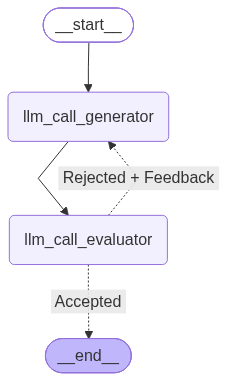

In [17]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [18]:
# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

Here are a few cat jokes you can use:

- Why don’t cats play poker in the jungle? Too many cheetahs.
- Why did the cat sit on the computer? It wanted to keep an eye on the mouse.
- What do you call a cat that can sing? A meow-sician.


## 8. Agents

Agents are typically implemented as an LLM performing actions using **tools**. They operate in continuous feedback loops and are used in situations where problems and solutions are unpredictable. Agents have more autonomy than workflows, and can make decisions about the tools they use and how to solve problems. You can still define the available toolset and guidelines for how agents behave.

![Agent](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/agent.png?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=bd8da41dbf8b5e6fc9ea6bb10cb63e38)

### 8.1 Define tools

In [20]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

### 8.2 Graph API

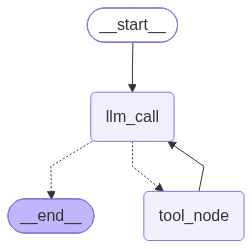

In [21]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [22]:
# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_b3qHmn4V1ssANPcukEVsZPc2)
 Call ID: call_b3qHmn4V1ssANPcukEVsZPc2
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

7


## 9. ToolNode

`ToolNode` is a prebuilt node that executes tools in LangGraph workflows. It handles parallel tool execution, error handling, and state injection automatically.

Use `ToolNode` when you need fine-grained control over how your graph executes tools. This is the building block that powers tool execution in many LangGraph agent patterns.

### 9.1 Basic usage

In [24]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState, START, StateGraph

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))

builder = StateGraph(MessagesState)
builder.add_node("tools", ToolNode([search, calculator]))
# ... add other nodes and edges
builder.add_edge(START, "tools")  # minimal entrypoint so this illustrative graph compiles
graph = builder.compile()

### 9.2 Access graph state and context from tools

Tools executed by `ToolNode` receive the arguments generated by the model as their first argument. To read graph-side data that was **not** generated by the model, read state and run-scoped context from the injected `ToolRuntime` argument.

> **Note:** Tools can only access the state values passed to the `ToolNode`. When `ToolNode` is added directly as a `StateGraph` node, that input is the current graph state. If you invoke a `ToolNode` manually from another node, pass the full state when tools need custom state fields — e.g. `tool_node.invoke(state)` exposes the full state, while passing only `{"messages": state["messages"]}` only exposes `messages`.

In [25]:
from dataclasses import dataclass

from langchain.messages import AIMessage
from langchain.tools import ToolRuntime, tool
from langgraph.graph import MessagesState, START, StateGraph
from langgraph.prebuilt import ToolNode


class State(MessagesState):
    user_id: str


@dataclass
class Context:
    organization_id: str


@tool
def get_user_info(runtime: ToolRuntime[Context, State]) -> str:
    """Look up user information."""
    # Read the current graph state passed to the ToolNode.
    user_id = runtime.state["user_id"]

    # Read explicit per-run values that are not part of graph state.
    organization_id = runtime.context.organization_id

    return f"User {user_id} in organization {organization_id}"


builder = StateGraph(State, context_schema=Context)
builder.add_node("tools", ToolNode([get_user_info]))
builder.add_edge(START, "tools")
graph = builder.compile()

result = graph.invoke(
    {
        "messages": [
            AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "get_user_info",
                        "args": {},
                        "id": "call_user_info",
                    }
                ],
            )
        ],
        "user_id": "user_123",
    },
    context=Context(organization_id="org_456"),
)
result

{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, id='7d62e733-320c-4038-b97d-dff115177330', tool_calls=[{'name': 'get_user_info', 'args': {}, 'id': 'call_user_info', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='User user_123 in organization org_456', name='get_user_info', id='121661e7-80ce-4fa7-bf09-e6684da4367c', tool_call_id='call_user_info')],
 'user_id': 'user_123'}

## Summary — Which pattern do I use?

| Pattern | Control | Flexibility | When to use |
|---|---|---|---|
| **Prompt Chaining** | Fixed sequence | Low | A task naturally decomposes into ordered, verifiable steps |
| **Parallelization** | Fixed, concurrent branches | Low–Medium | Independent subtasks, or the same task run multiple times for confidence |
| **Routing** | Fixed branches, dynamic choice | Medium | Distinct input types each need a specialized flow |
| **Orchestrator-Worker** | Dynamic subtask count | Medium–High | Subtasks can't be predefined (e.g. unknown number of files/sections) |
| **Evaluator-Optimizer** | Loop until criteria met | Medium–High | Clear success criteria, but it takes iteration to hit it |
| **Agent** | Model decides everything | Highest | Problems and solutions are unpredictable; the model should choose its own tools/steps |

**Key takeaway:** workflows trade autonomy for predictability and control — start with the most constrained pattern that solves your problem, and only reach for a full agent when the task genuinely needs open-ended tool use and decision-making.
